# Customer Behavior & Revenue Correlation Analysis — NovaRetail+
### Data Analysis Project with Python, Pandas & Statistical Testing

**Author:** David Anampa

This project investigates which customer behavior factors are most strongly associated with the annual revenue generated by users of NovaRetail+, a Latin American e-commerce platform, using a correlational analysis approach.

## Project Overview

Ahead of the 2024 year-end review, the Growth & Retention team wanted to answer:

**Which customer behavior factors are most strongly associated with annual revenue generated?**

This is a **correlational (exploratory)** analysis. Throughout the project, correlation is treated strictly as association rather than causation — every finding is framed in non-causal language and paired with an explicit statement of what the data cannot support.

The workflow includes:

- Data exploration and validation
- Column standardization and data cleaning
- Variable classification (numeric, binary, categorical)
- Correlation analysis using coefficients appropriate to each variable type (Pearson, Spearman, point-biserial, Cramér's V)
- Visualization of key relationships
- Business interpretation of findings
- Limitations and recommended next steps

## 1. Data Loading & Initial Exploration

The first stage focuses on importing the dataset and validating its structure, data types, and overall quality before preprocessing.

In [1]:
# importar librerías
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chi2_contingency

In [3]:
# cargar el dataset
# load the dataset
df = pd.read_csv('dataset/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


### Dataset Description

The dataset contains **15,000 records** and **12 columns**, with no missing values. It includes the following columns:

- `id_cliente` — Unique customer identifier
- `edad` — Customer age
- `nivel_ingreso` — Estimated annual income
- `visitas_mes` — Number of app/website visits during the month
- `compras_mes` — Number of purchases made during the month
- `gasto_publicidad_dirigida` — Targeted advertising spend allocated to the user
- `satisfaccion` — Customer satisfaction score (1–5)
- `miembro_premium` — Whether the customer holds a premium subscription (1) or not (0)
- `abandono` — Whether the customer churned (1) or not (0)
- `tipo_dispositivo` — Device type used (mobile, desktop, tablet)
- `region` — Customer's geographic region (north, south, east, west)
- `ingreso_anual` — Annual revenue generated by the customer for the company

The main metric of interest is `ingreso_anual`, used to evaluate the economic impact of customers.

In [ ]:
# mostrar las primeras 5 filas
# show the first 5 rows
df.head(5)

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## 2. Data Cleaning & Column Standardization

Column names were translated and standardized to English snake_case to improve readability and keep the project consistent with the rest of the portfolio.

In [5]:
# estandarizar los nombres de las columnas
# standardize column names
df = df.rename(columns={
    'id_cliente': 'customer_id',
    'edad': 'age',
    'nivel_ingreso': 'income_level',
    'visitas_mes': 'monthly_visits',
    'compras_mes': 'monthly_purchases',
    'gasto_publicidad_dirigida': 'targeted_ad_spend',
    'satisfaccion': 'satisfaction_score',
    'miembro_premium': 'premium_member',
    'abandono': 'churn',
    'tipo_dispositivo': 'device_type',
    'region': 'region',
    'ingreso_anual': 'annual_revenue'
})

# verificar cambios
# verify changes
df.columns

Index(['customer_id', 'age', 'income_level', 'monthly_visits',
       'monthly_purchases', 'targeted_ad_spend', 'satisfaction_score',
       'premium_member', 'churn', 'device_type', 'region', 'annual_revenue'],
      dtype='object')

In [6]:
# corregir el tipo de dato de age
# fix the data type of age
df['age'] = df['age'].astype('int')

# verificar cambios
# verify changes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         15000 non-null  object 
 1   age                 15000 non-null  int64  
 2   income_level        15000 non-null  float64
 3   monthly_visits      15000 non-null  int64  
 4   monthly_purchases   15000 non-null  int64  
 5   targeted_ad_spend   15000 non-null  float64
 6   satisfaction_score  15000 non-null  float64
 7   premium_member      15000 non-null  int64  
 8   churn               15000 non-null  int64  
 9   device_type         15000 non-null  object 
 10  region              15000 non-null  object 
 11  annual_revenue      15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


## 3. Variable Classification & Descriptive Diagnostics

Before running any correlation analysis, each variable was classified into exactly one type — numeric, binary, or categorical — since the coefficient used later depends directly on this classification.

- **Numeric:** `age`, `income_level`, `monthly_visits`, `monthly_purchases`, `targeted_ad_spend`, `satisfaction_score`, `annual_revenue`
- **Binary:** `premium_member`, `churn` (already encoded as 0/1, no transformation required)
- **Categorical:** `device_type`, `region` (`customer_id` is a unique identifier and carries no analytical value, so it is excluded from the analysis)

### Numeric Variables

In [7]:
# estadísticas descriptivas de variables numéricas
# descriptive statistics of numeric variables
df.describe()

,age,income_level,monthly_visits,monthly_purchases,targeted_ad_spend,satisfaction_score,premium_member,churn,annual_revenue
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


**Diagnosis — numeric variables**

- `age`: average age of 38 years, with most customers between 30 and 46 (range 18–75).
- `income_level`: average of roughly 30k, with a wide spread across customers (8k to nearly 75k).
- `monthly_visits`: customers average 10 visits per month, mostly concentrated between 8 and 12.
- `monthly_purchases`: low average (1.2 purchases/month); half of customers make one purchase or fewer.
- `targeted_ad_spend`: average of 20 units, with considerable variability (0 to 75.5).
- `satisfaction_score`: average of 3.6 out of 5, concentrated around medium-high levels.
- `annual_revenue`: average of 36.6, with high variability and a maximum of 244.7.

### Binary Variables

In [8]:
# verificar que cada columna tenga únicamente dos valores posibles
# verify that each column has only two possible values
df[['premium_member', 'churn']].describe()

,premium_member,churn
count,15000.000000,15000.000000
mean,0.139267,0.150733
std,0.346236,0.357801
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,1.000000,1.000000


**Diagnosis — binary variables**

- `premium_member`: only 13.9% of customers belong to the premium program.
- `churn`: 15.1% of customers have churned.

### Categorical Variables

In [9]:
# verificar el número de valores únicos por variable categórica
# verify the number of unique values per categorical variable
df[['device_type', 'region']].describe()

,device_type,region
count,15000,15000
unique,3,4
top,móvil,norte
freq,9818,4395


In [10]:
# explorar la distribución de variables categóricas
# explore the distribution of categorical variables
df[['device_type', 'region']].value_counts()

device_type  region
móvil        norte     2843
             oeste     2489
             sur       2483
             este      2003
escritorio   norte     1125
             oeste      935
             sur        894
             este       766
tablet       norte      427
             oeste      386
             sur        349
             este       300
Name: count, dtype: int64

**Diagnosis — categorical variables**

- `device_type`: mobile is the dominant device (roughly 7,815 records), well ahead of desktop and tablet. Tablet has the fewest users.
- `region`: fairly balanced distribution across regions, with north slightly higher and east slightly lower.

### Assumptions

- The analysis uses the entire available dataset.
- The data is assumed to be correctly typed with no structural errors.
- Different coefficients are used depending on variable type:
  - **Pearson** assumes linear relationships between numeric variables.
  - **Spearman** evaluates monotonic relationships and does not require normality.
  - **Point-biserial** is used for numeric–binary relationships.
  - **Cramér's V** is used for associations between categorical variables.

**Central assumption:** this analysis identifies relationships between variables or segments, but it does not test or establish causality.

## 4. Visualization of Relationships

Numeric variables are visualized to identify patterns of association before computing formal correlation coefficients.

### Correlation Heatmap

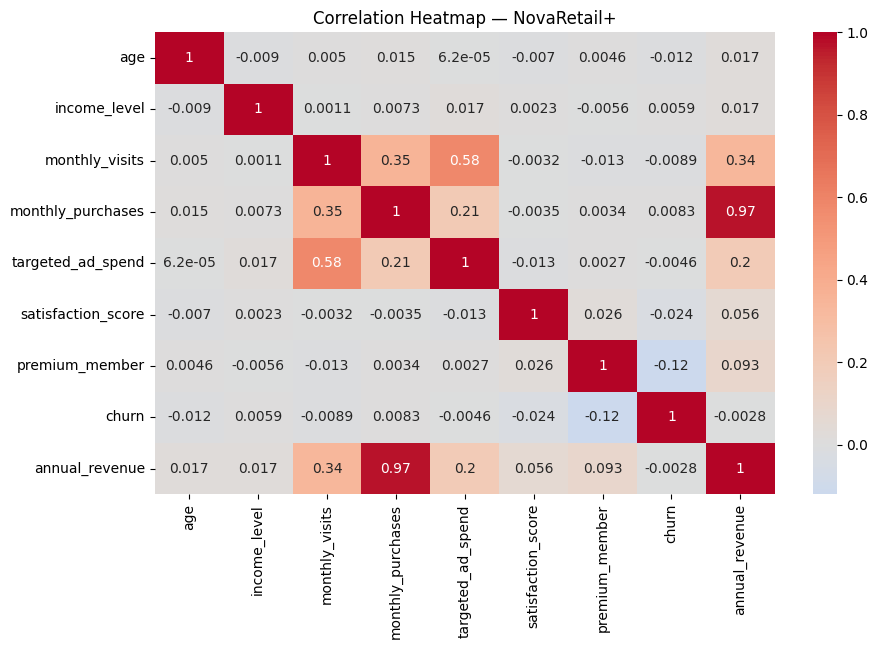

In [11]:
# visualizar la matriz de correlación para identificar relaciones
# visualize the correlation matrix to identify relationships
numeric_cols = [
    'age',
    'income_level',
    'monthly_visits',
    'monthly_purchases',
    'targeted_ad_spend',
    'satisfaction_score',
    'premium_member',
    'churn',
    'annual_revenue'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — NovaRetail+")
plt.show()

**Key Observations — Heatmap**

- Most variable pairs show correlations close to 0, indicating little linear relationship between them.
- `monthly_visits` and `targeted_ad_spend` show a moderate positive correlation (0.58): customers with more visits tend to be associated with higher targeted ad spend.
- `monthly_visits` and `monthly_purchases` show a weaker positive relationship (0.35).
- `age`, `income_level`, and `satisfaction_score` show no relevant correlations with the other variables.

Regarding `annual_revenue` specifically:

- Very high correlation with `monthly_purchases` (0.97), suggesting the two variables behave almost equivalently in this dataset, despite measuring conceptually different things (purchase frequency vs. revenue generated).
- Moderate correlation with `monthly_visits` (0.34), suggesting visit frequency is associated with higher annual revenue.
- Low correlation with `targeted_ad_spend` (0.20).
- No relevant relationship with `age`, `satisfaction_score`, `churn`, or `income_level`.

These relationships show association between variables, but do not indicate that one variable causes changes in another.

### General Scatterplot

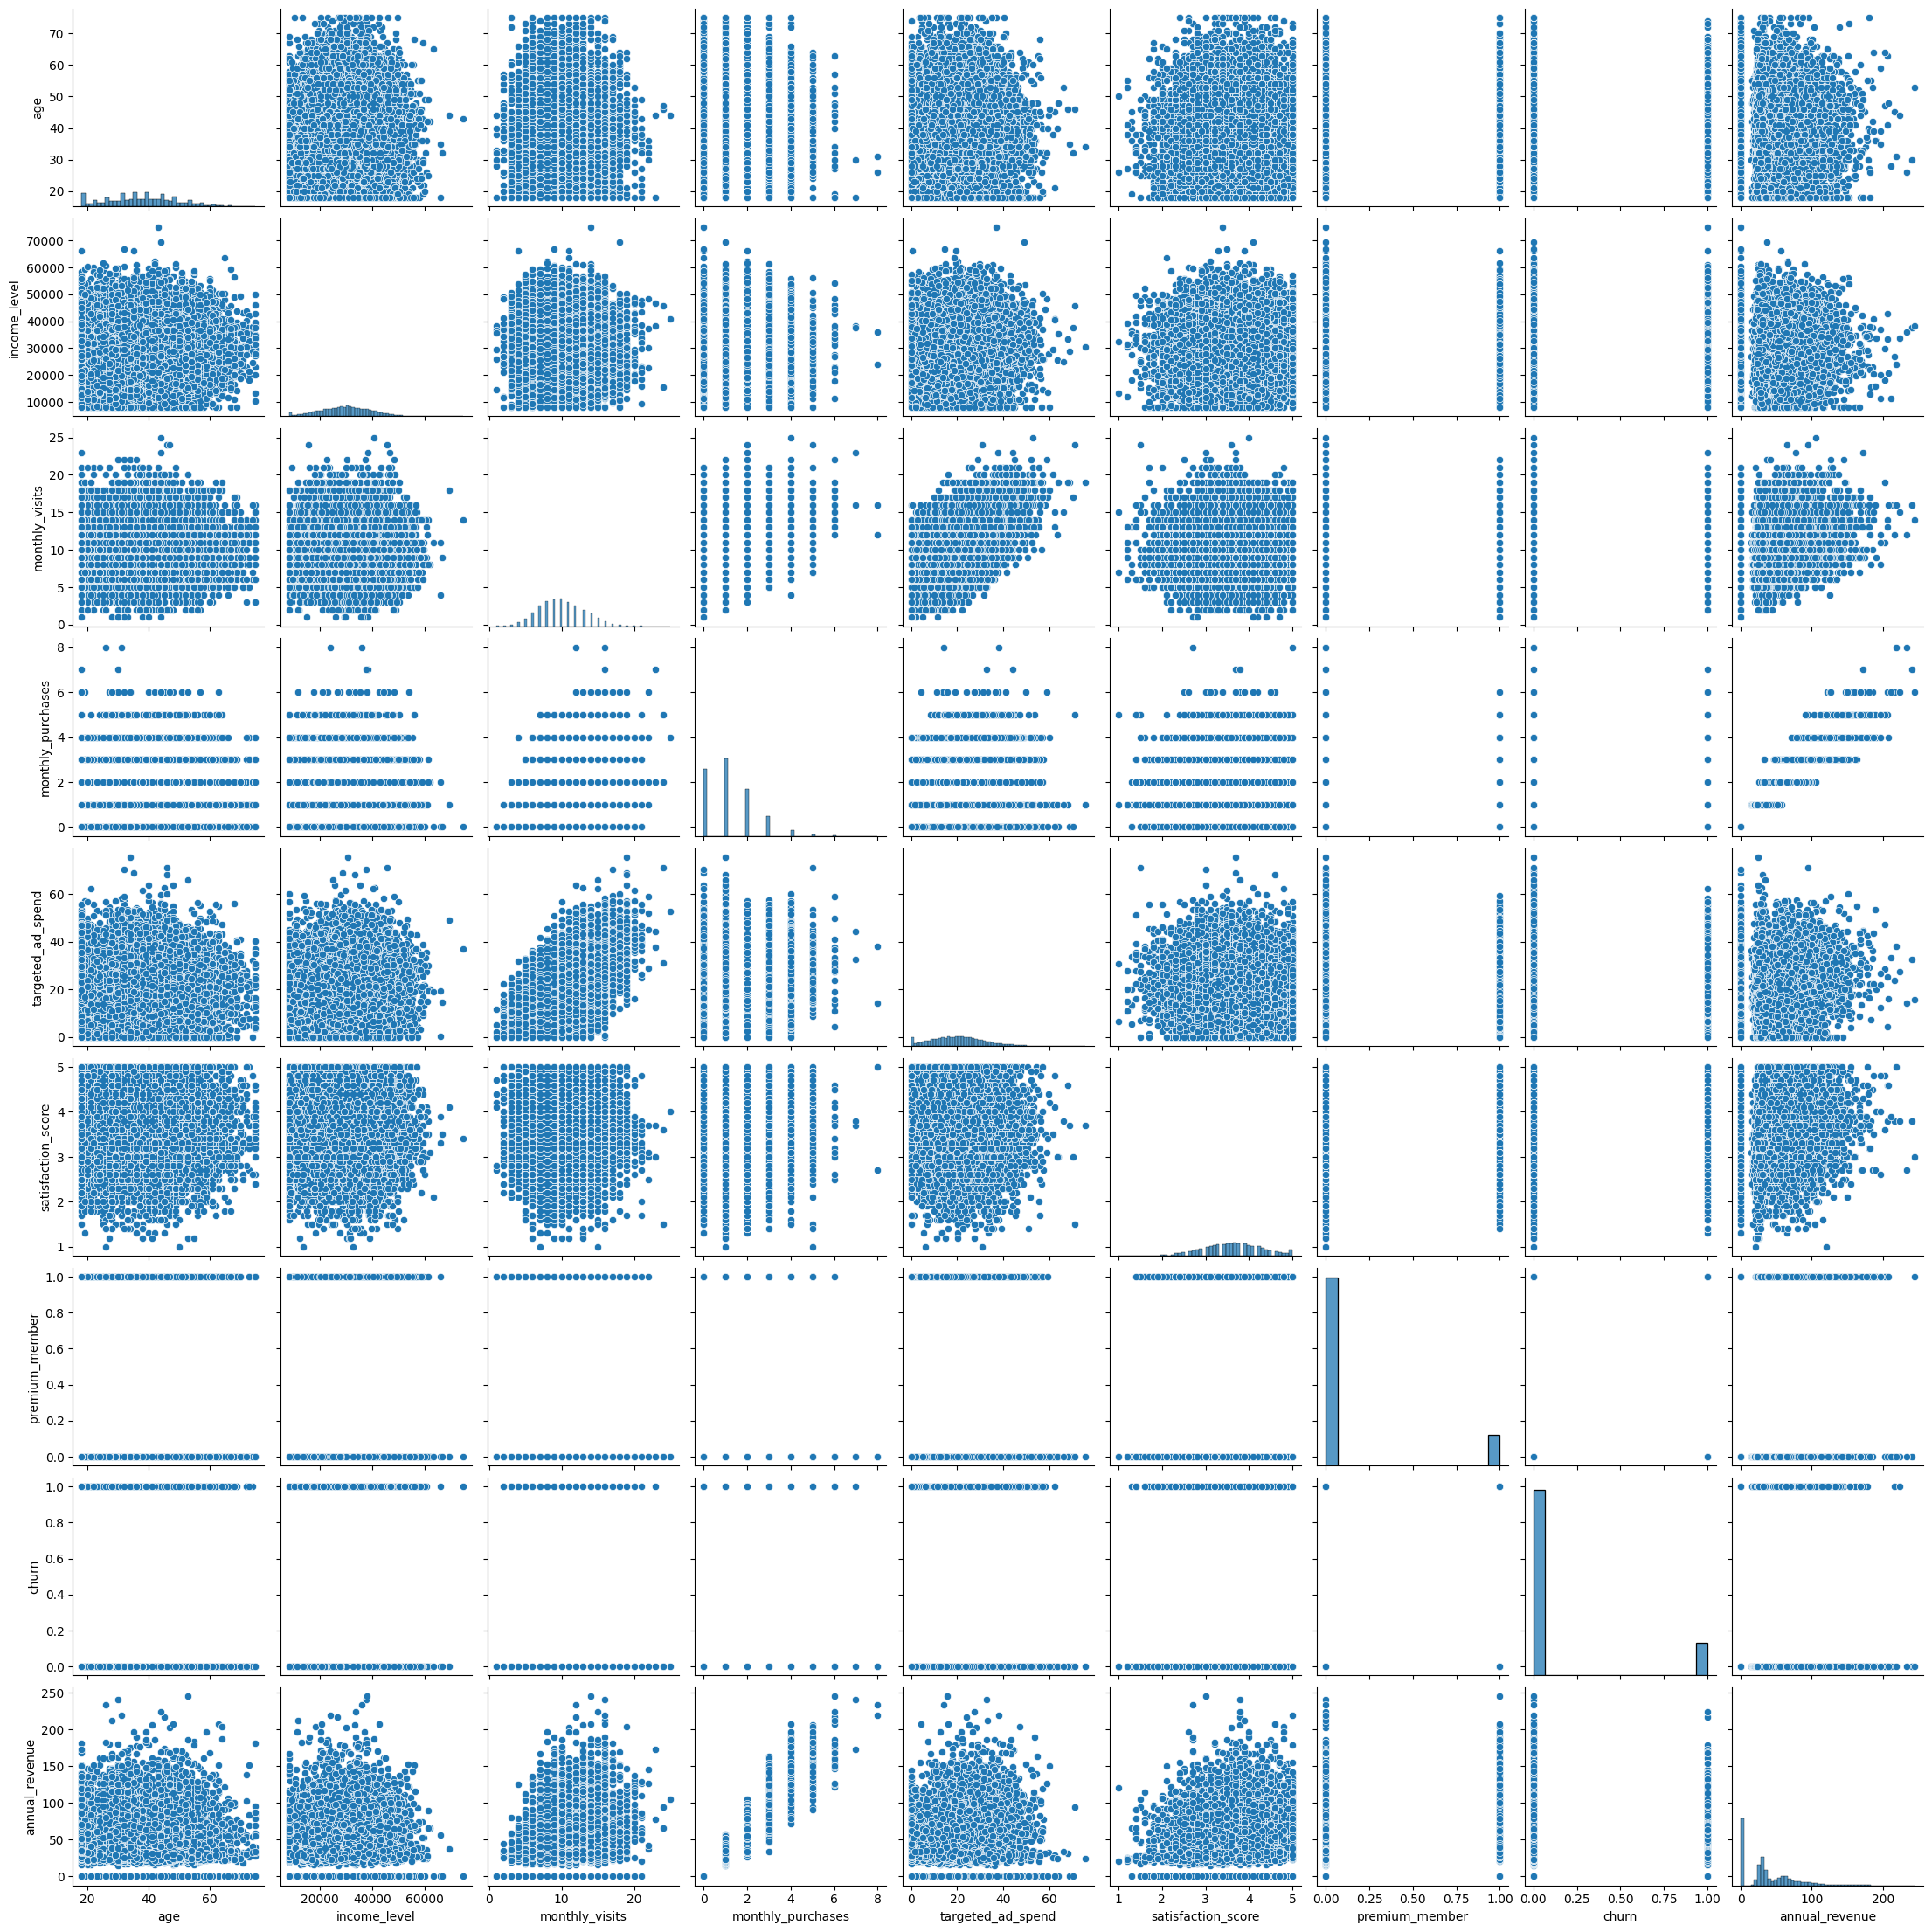

In [12]:
# scatterplot general de variables numéricas
# general scatterplot of numeric variables
sns.pairplot(df[numeric_cols])
plt.show()

### Scatterplots for Key Variable Pairs

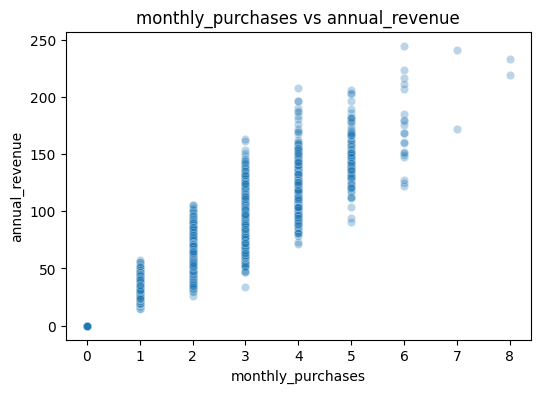

In [13]:
# visualizar pares de variables con relaciones moderadas o fuertes
# visualize variable pairs with moderate or strong relationships

# monthly_purchases vs annual_revenue (correlation 0.97)
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='monthly_purchases', y='annual_revenue', alpha=0.3)
plt.title("monthly_purchases vs annual_revenue")
plt.show()

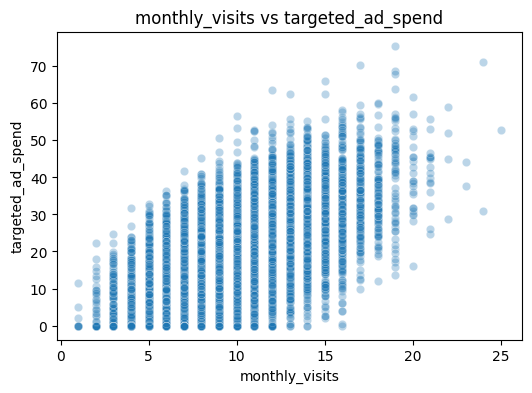

In [14]:
# monthly_visits vs targeted_ad_spend (correlation 0.58)
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='monthly_visits', y='targeted_ad_spend', alpha=0.3)
plt.title("monthly_visits vs targeted_ad_spend")
plt.show()

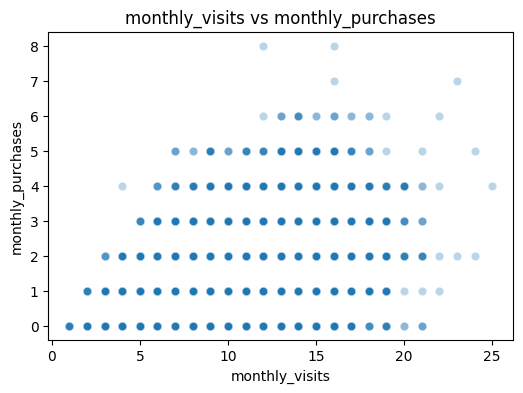

In [15]:
# monthly_visits vs monthly_purchases (correlation 0.35)
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='monthly_visits', y='monthly_purchases', alpha=0.3)
plt.title("monthly_visits vs monthly_purchases")
plt.show()

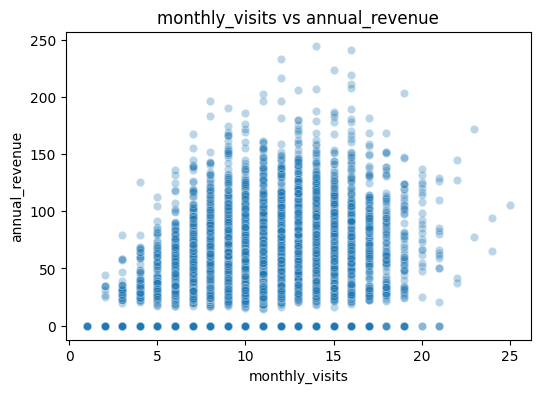

In [16]:
# monthly_visits vs annual_revenue (correlation 0.34)
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='monthly_visits', y='annual_revenue', alpha=0.3)
plt.title("monthly_visits vs annual_revenue")
plt.show()

**Key Observations — Scatterplots**

- **monthly_purchases vs annual_revenue:** strong positive direction with low dispersion and a near-linear pattern; no relevant outliers. The near-perfect correlation (0.97) suggests high potential collinearity — both variables likely capture very similar information.
- **monthly_visits vs targeted_ad_spend:** positive direction with medium dispersion; the moderate correlation (0.58) shows association without redundancy.
- **monthly_visits vs monthly_purchases:** positive direction with medium-high dispersion; the moderate correlation (0.35) suggests the two variables add different information.
- **monthly_visits vs annual_revenue:** positive direction with medium-high dispersion; the moderate correlation (0.34) does not indicate a redundant relationship.

## 5. Correlation Coefficients & Statistical Evidence

This section reports the coefficients that support the patterns observed visually, using the method appropriate to each pair's variable types.

### Pearson & Spearman

In [17]:
# calcular la correlación de Pearson entre variables relevantes
# calculate the Pearson correlation between relevant variables
relevant_pairs = [
    ('monthly_purchases', 'annual_revenue'),
    ('monthly_visits', 'targeted_ad_spend'),
    ('monthly_visits', 'monthly_purchases'),
    ('monthly_visits', 'annual_revenue')
]

for x, y in relevant_pairs:
    r, p = stats.pearsonr(df[x], df[y])
    print(f"{x} vs {y} — Pearson: {r:.4f}")

monthly_purchases vs annual_revenue — Pearson: 0.9671
monthly_visits vs targeted_ad_spend — Pearson: 0.5789
monthly_visits vs monthly_purchases — Pearson: 0.3538
monthly_visits vs annual_revenue — Pearson: 0.3371


In [18]:
# calcular la correlación de Spearman entre las mismas variables
# calculate the Spearman correlation for the same variables
for x, y in relevant_pairs:
    r, p = stats.spearmanr(df[x], df[y])
    print(f"{x} vs {y} — Spearman: {r:.4f}")

monthly_purchases vs annual_revenue — Spearman: 0.9675
monthly_visits vs targeted_ad_spend — Spearman: 0.5593
monthly_visits vs monthly_purchases — Spearman: 0.3329
monthly_visits vs annual_revenue — Spearman: 0.3210


**Diagnosis — Pearson & Spearman**

- **monthly_purchases vs annual_revenue:** very strong positive correlation (Pearson = 0.9671, Spearman = 0.9675). Both variables behave almost equivalently in the data, possibly capturing the same underlying trend from different angles. The relationship is statistically significant, though correlation does not imply causation.
- **monthly_visits vs targeted_ad_spend:** moderate positive correlation (Pearson = 0.5789, Spearman = 0.5593). Customers with more visits tend to be associated with higher targeted ad spend, and the similarity between both methods indicates the relationship is consistent (not driven by outliers or non-linearity).
- **monthly_visits vs monthly_purchases:** moderate-low positive correlation (Pearson = 0.3538, Spearman = 0.3329). More visits tend to relate to more purchases, but the relationship is limited.
- **monthly_visits vs annual_revenue:** moderate-low positive correlation (Pearson = 0.3371, Spearman = 0.3210). Customers with more visits tend to show higher annual revenue, though the association is limited and may be influenced by other unmeasured factors.

### Point-Biserial Correlation

In [19]:
# correlación punto-biserial: premium_member vs annual_revenue
# point-biserial correlation: premium_member vs annual_revenue
r, p = stats.pointbiserialr(df['premium_member'], df['annual_revenue'])
print(f"premium_member vs annual_revenue — r: {r:.4f}, p-value: {p:.4f}")

premium_member vs annual_revenue — r: 0.0931, p-value: 0.0000


In [20]:
# correlación punto-biserial: churn vs annual_revenue
# point-biserial correlation: churn vs annual_revenue
r, p = stats.pointbiserialr(df['churn'], df['annual_revenue'])
print(f"churn vs annual_revenue — r: {r:.4f}, p-value: {p:.4f}")

churn vs annual_revenue — r: -0.0028, p-value: 0.7295


**Diagnosis — point-biserial**

- **premium_member vs annual_revenue:** very weak positive relationship (r = 0.0931). Being a premium member shows little association with higher annual revenue.
- **churn vs annual_revenue:** essentially null relationship (r = -0.0028). No meaningful association between churn and annual revenue, consistent with what was observed in the heatmap.

### Cramér's V

In [22]:
# función para calcular la V de Cramér
# function to calculate Cramér's V
def cramers_v(dataframe, col1, col2):
    table = pd.crosstab(dataframe[col1], dataframe[col2])
    chi2, p_value, dof, expected = chi2_contingency(table)
    n = table.values.sum()
    v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))
    return v, p_value

In [23]:
# aplicar la V de Cramér en variables categóricas relevantes
# apply Cramér's V to relevant categorical variables
categorical_pairs = [
    ('device_type', 'region'),
    ('device_type', 'churn'),
    ('region', 'churn'),
    ('device_type', 'premium_member')
]

for x, y in categorical_pairs:
    v, p = cramers_v(df, x, y)
    print(f"{x} vs {y} — Cramér's V: {v:.4f}, p-value: {p:.4f}")

device_type vs region — Cramér's V: 0.0124, p-value: 0.5965
device_type vs churn — Cramér's V: 0.0072, p-value: 0.6746
region vs churn — Cramér's V: 0.0154, p-value: 0.3117
device_type vs premium_member — Cramér's V: 0.0197, p-value: 0.0540


**Diagnosis — Cramér's V**

- **device_type vs region:** essentially null association (V = 0.0124).
- **device_type vs churn:** practically nonexistent association (V = 0.0072).
- **region vs churn:** very weak association (V = 0.0154).
- **device_type vs premium_member:** very weak association (V = 0.0197). Although the p-value is close to the significance threshold (0.054), the effect size is negligible, so this is not considered a relevant association.

## 6. Business Interpretation of Findings

Each finding below follows the same structure: visual evidence, numerical evidence, non-causal interpretation, what cannot be claimed, and the business implication.

### Finding 1 — Monthly purchases and annual revenue

**Visual evidence:** the scatterplot shows a very clear positive trend between `monthly_purchases` and `annual_revenue`, with low dispersion and near-linear behavior.

**Numerical evidence:** Pearson = 0.9671, Spearman = 0.9675.

**Interpretation:** there is a very strong positive association between the number of monthly purchases and annual revenue. Both variables behave almost equivalently in the dataset, which could indicate redundant information.

**What we cannot claim:** we cannot claim that an increase in monthly purchases directly causes an increase in annual revenue, since correlation does not imply causation.

**Business implication:** `monthly_purchases` can be a useful variable for estimating customer revenue behavior, though its high similarity to `annual_revenue` should be taken into account (e.g., avoid using both as independent predictors in the same model).

### Finding 2 — Monthly visits and targeted ad spend

**Visual evidence:** the scatterplot shows a moderate positive trend between `monthly_visits` and `targeted_ad_spend`, with some dispersion in the data.

**Numerical evidence:** Pearson = 0.5789, Spearman = 0.5593.

**Interpretation:** there is a moderate positive association between monthly visits and targeted ad spend. Customers with more visits tend to show higher levels of targeted advertising spend.

**What we cannot claim:** we cannot claim that higher ad spend directly causes more visits, since other factors may influence this relationship.

**Business implication:** visit frequency could be used as an indicator to analyze customer engagement patterns and refine segmentation or targeted advertising strategies.

### Finding 3 — No relevant relationship between churn and annual revenue

**Visual evidence:** the heatmap and correlation analysis show no clear relationship between `churn` and `annual_revenue`.

**Numerical evidence:** point-biserial correlation = -0.0028.

**Interpretation:** churn shows an essentially null relationship with annual revenue in the analyzed data.

**What we cannot claim:** we cannot claim that customers with higher or lower revenue are more likely to churn.

**Business implication:** retention strategies should not be based solely on a customer's revenue level.

### Finding 4 — No relevant association among categorical variables

**Visual evidence:** distributions across categories show no meaningful differences between region, device, churn, or premium membership.

**Numerical evidence:**
- `device_type` vs `region`: Cramér's V = 0.0124
- `device_type` vs `churn`: Cramér's V = 0.0072
- `region` vs `churn`: Cramér's V = 0.0154

**Interpretation:** the categorical variables analyzed show practically nonexistent associations.

**What we cannot claim:** we cannot claim that region or device type influence churn or premium membership.

**Business implication:** segmentation based solely on location or device is unlikely to add significant predictive value for customer behavior.

## 7. Limitations & Next Steps

**Limitations**

- Correlation ≠ causation. The relationships found show association between variables, but do not establish cause and effect.
- The analysis focused on pairwise relationships, so interactions between multiple factors were not evaluated.
- Some variables have specific characteristics (e.g., discrete or ordinal variables) that can limit the interpretation of certain metrics.
- The high correlation between `monthly_purchases` and `annual_revenue` may indicate redundant information between the two.

**Next Steps**

- **Additional segmentation:** analyze behavioral differences across customer groups (e.g., premium vs. non-premium) and build segments combining purchase frequency, visits, and revenue.
- **Predictive modeling:** apply predictive models to identify which variables best explain churn or annual revenue.
- **Temporal analysis:** evaluate changes in purchase and retention patterns over time.

## Project Deliverables

- Complete Jupyter Notebook with the full analysis workflow
- Statistical evidence (Pearson, Spearman, point-biserial, Cramér's V) supporting each finding
- Visualizations for portfolio presentation
- Business-oriented interpretation of results

# Executive Summary

## Objective
This project analyzes which customer behavior factors are most strongly associated with the annual revenue generated by NovaRetail+ customers, using a correlational (non-causal) approach.

## Methodology
The workflow included data cleaning and column standardization, variable classification by type, exploratory visualization (heatmap, pairplot, scatterplots), and the application of Pearson, Spearman, point-biserial, and Cramér's V coefficients depending on variable type.

## Main Findings
- `monthly_purchases` shows a very strong association with `annual_revenue` (Pearson ≈ 0.97), though the two variables likely carry redundant information.
- `monthly_visits` shows moderate associations with `targeted_ad_spend`, `monthly_purchases`, and `annual_revenue`.
- `premium_member` and `churn` show negligible association with `annual_revenue`.
- Categorical variables (`device_type`, `region`) show no relevant association with churn or premium membership.

## Business Recommendations
- Use purchase frequency and visit frequency as engagement indicators, being mindful of redundancy between purchase-based metrics and revenue.
- Avoid basing retention or segmentation strategies solely on revenue level, device type, or region, as none of these show a strong standalone relationship with churn.
- Prioritize predictive modeling and temporal analysis as the next stage to move beyond pairwise correlations.